In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/AirBnB_all_chch.csv")

In [3]:
df["last_review"] = pd.to_datetime(df["last_review"])

In [4]:
df.groupby("year_month")["last_review"].max()

year_month
2025-10   2025-10-08
2025-11   2025-11-20
2025-12   2025-12-12
2026-1    2026-01-23
2026-2    2026-02-15
2026-3    2026-03-22
2026-4    2026-04-22
2026-5    2026-06-02
2026-6    2026-06-21
Name: last_review, dtype: datetime64[ns]

Above shows the reference date for each month, it is the most recent last_review date from Airbnbs in the Christchurch City area. This avoids negative numbers and is a more streamlined system than looking back into another file on the Inside Airbnb website at the last scraped date which adds unnecessary steps that do not change the pattern of the data. 

In [5]:
ref_date = df.groupby("year_month")["last_review"].transform("max")

In [6]:
df["days_since_review"] = (ref_date - df["last_review"]).dt.days

In [7]:
june = df[df["year_month"] == "2026-6"]

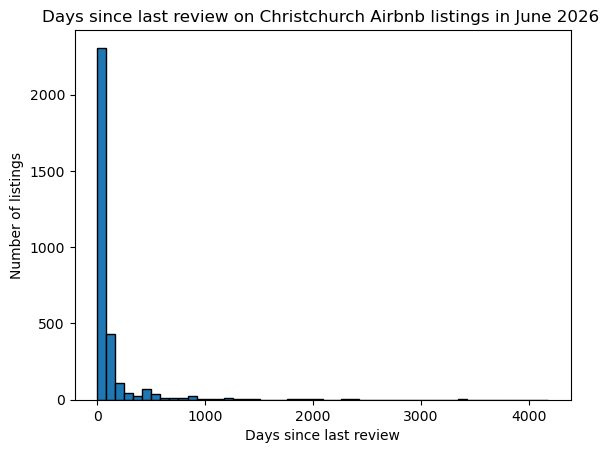

In [8]:
plt.hist(june["days_since_review"], bins=50, edgecolor="black")
plt.title("Days since last review on Christchurch Airbnb listings in June 2026 ")
plt.xlabel("Days since last review")
plt.ylabel("Number of listings")
plt.show()

This Christchurch data continues to show the same trend as New Zealand data where it is heavily right skewed.